# 04 - Chromagram and chord detection

This is where the project moves from "signal analysis" into "music analysis". The goal is to extract a **chord sequence** from raw audio. Procedure:

1. **Chromagram** - collapse the spectrum into a 12-dimensional vector per chroma (C, C#, ..., B), ignoring octave.
2. **Chord templates** - build templates for major and minor triads.
3. **Detection** - compare the chromagram against the templates and pick the best match.
4. **Evaluation** - compare against the true chords.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
from matplotlib import pyplot as plt

import common as C
import chroma as CH

## 1. Why chroma?

The human ear perceives tones an octave apart as "the same note". That's why octave doesn't matter for chord recognition - what matters is only the **chroma** (pitch class): which of the 12 basic tones (C, C#, D, ..., B) is sounding, and how strongly. We map a frequency $f$ to a chroma using the formula

$$\text{chroma} = \big(\mathrm{round}(69 + 12\log_2(f/440))\big) \bmod 12.$$

In [2]:
# Check for some well-known notes which chroma they map into
for name in ['C', 'E', 'G', 'A']:
    idx = C.NOTE_NAMES.index(name)
    f = C.note_to_freq(60 + idx)   # octave 4
    print('%s4 = %.1f Hz -> chroma %d (%s)' % (name, f, C.freq_to_chroma(f), C.NOTE_NAMES[C.freq_to_chroma(f)]))

C4 = 261.6 Hz -> chroma 0 (C)
E4 = 329.6 Hz -> chroma 4 (E)
G4 = 392.0 Hz -> chroma 7 (G)
A4 = 440.0 Hz -> chroma 9 (A)


## 2. Chromagram of a rising scale

Let's generate a C major scale and look at its chromagram. We expect diagonal "steps" as the chroma rises, with a jump back to C after B (because octave is ignored).

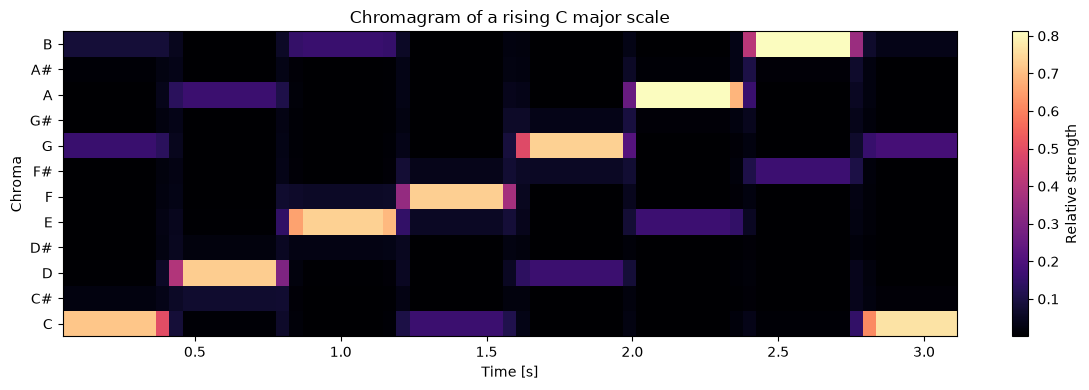

In [3]:
Fs = 44100
midi_notes = [60, 62, 64, 65, 67, 69, 71, 72]     # C4..C5
parts = [C.generate_tone(C.note_to_freq(m), 0.4, Fs, num_harmonics=4) for m in midi_notes]
scale = np.hstack(parts)

times, H = CH.chromagram(scale, Fs)
CH.plot_chromagram(times, H, title='Chromagram of a rising C major scale')
plt.show()

## 3. Chord templates

For each of the 12 roots we build:
- a **major triad**: root, major third (+4), fifth (+7),
- a **minor triad**: root, minor third (+3), fifth (+7).

Each template is a binary vector of length 12.

In [4]:
templates = CH.make_chord_templates()
print('Total templates:', len(templates), '(12 major + 12 minor)')
print()
print('C:maj  =', templates['C:maj'].astype(int), '  (C, E, G)')
print('A:min  =', templates['A:min'].astype(int), '  (A, C, E)')

Total templates: 24 (12 major + 12 minor)

C:maj  = [1 0 0 0 1 0 0 1 0 0 0 0]   (C, E, G)
A:min  = [1 0 0 0 1 0 0 0 0 1 0 0]   (A, C, E)


## 4. Chord detection on a synthetic progression

We test on the classic **I–vi–IV–V** progression in C major (C major → A minor → F major → G major). For each chord we average the chromagram over time and compare against the templates (cosine similarity).

In [5]:
def nf(name, octave):
    idx = C.NOTE_NAMES.index(name)
    return C.note_to_freq((octave + 1) * 12 + idx)

progression = [
    ('C:maj', ['C', 'E', 'G']),
    ('A:min', ['A', 'C', 'E']),
    ('F:maj', ['F', 'A', 'C']),
    ('G:maj', ['G', 'B', 'D']),
]

np.random.seed(4)
true_chords, detected_chords = [], []
print('%-8s %-10s %-8s' % ('true', 'detected', 'similarity'))
print('-' * 28)
for name, notes in progression:
    freqs = [nf(n, 4) for n in notes]
    sig = C.generate_chord(freqs, 1.0, Fs, num_harmonics=4, noise_std=0.01)
    _, Hac = CH.chromagram(sig, Fs)
    det, sim = CH.detect_chord(Hac.mean(axis=1))
    true_chords.append(name); detected_chords.append(det)
    print('%-8s %-10s %.3f' % (name, det, sim))

print('-' * 28)
print('Accuracy: %.0f%%' % (100 * CH.detection_accuracy(detected_chords, true_chords)))

true     detected   similarity
----------------------------
C:maj    C:maj      0.970
A:min    A:min      0.974
F:maj    F:maj      0.977
G:maj    G:maj      0.977
----------------------------
Accuracy: 100%


Detection is **100%** accurate on the clean synthetic case, with high similarity (≈0.97). This confirms the whole chain (STFT => chromagram => templates => comparison) works correctly before we move on to "messy" real audio.

## 5. The whole progression as a single signal (chords over time)

Let's join the four chords into a single recording and detect the chord at every time instant of the chromagram - this is already the "real" output of the music analysis system.

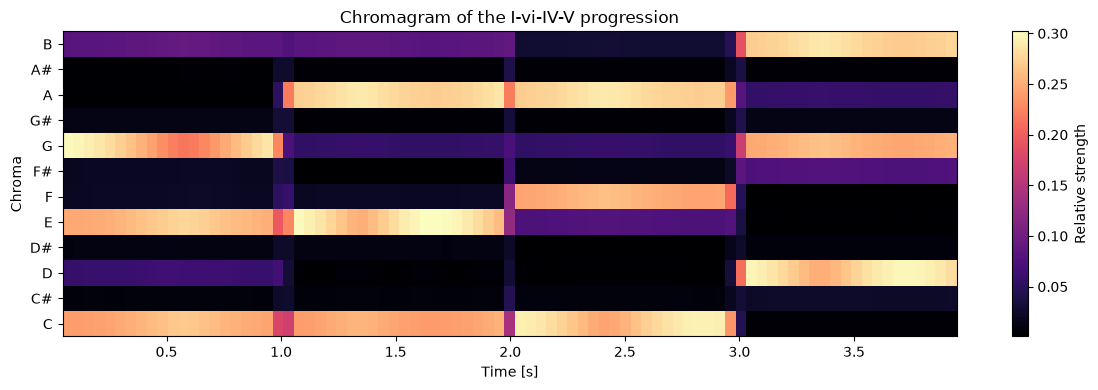

Detected chords (sampled over time):
  t=0.05s  =>  C:maj    (0.97)
  t=0.51s  =>  C:maj    (0.96)
  t=0.98s  =>  C:maj    (0.92)
  t=1.44s  =>  A:min    (0.97)
  t=1.90s  =>  A:min    (0.97)
  t=2.37s  =>  F:maj    (0.97)
  t=2.83s  =>  F:maj    (0.98)
  t=3.30s  =>  G:maj    (0.98)
  t=3.76s  =>  G:maj    (0.98)


In [6]:
parts = []
for _, notes in progression:
    freqs = [nf(n, 4) for n in notes]
    parts.append(C.generate_chord(freqs, 1.0, Fs, num_harmonics=4, noise_std=0.01))
song = np.hstack(parts)

times, H = CH.chromagram(song, Fs)
sequence = CH.detect_chord_sequence(times, H)

# Show the chromagram with the detected chords over time
CH.plot_chromagram(times, H, title='Chromagram of the I-vi-IV-V progression')
plt.show()

# Print the detected chords at a few sampled time instants
print('Detected chords (sampled over time):')
for t, chord, sim in sequence[::len(sequence)//8]:
    print('  t=%.2fs  =>  %-8s (%.2f)' % (t, chord, sim))

## 6. Evaluation against the true chords

Since we generated the progression ourselves, we know the true chord at every time instant, so we can compute the overall detection accuracy across the whole recording.

In [7]:
# True chord for every time instant (each chord lasts 1 s)
true_over_time = []
for t, _, _ in sequence:
    chord_index = min(int(t), len(progression) - 1)
    true_over_time.append(progression[chord_index][0])

detected_over_time = [chord for _, chord, _ in sequence]
accuracy = CH.detection_accuracy(detected_over_time, true_over_time)
print('Overall detection accuracy across the whole recording: %.1f%%' % (100 * accuracy))

Overall detection accuracy across the whole recording: 100.0%


## 7. Real recording

Finally, the same procedure on `piano.wav`. Real audio is "messy" (background tones, harmonics, multiple notes at once), so similarities are lower and errors are possible.

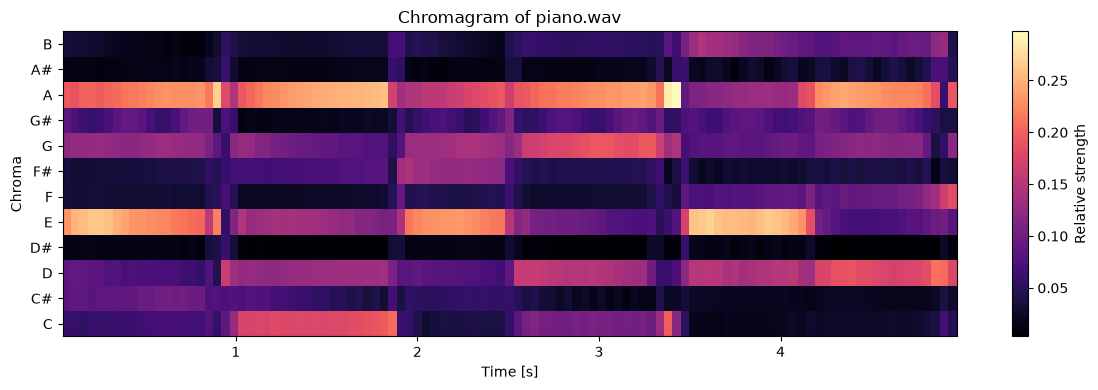

Dominant chord of the whole recording: A:min (similarity 0.738)


In [8]:
import warnings; warnings.filterwarnings('ignore')
Fs, piano = C.load_wav('../data/piano.wav')

times, H = CH.chromagram(piano, Fs)
CH.plot_chromagram(times, H, title='Chromagram of piano.wav')
plt.show()

det, sim = CH.detect_chord(H.mean(axis=1))
print('Dominant chord of the whole recording: %s (similarity %.3f)' % (det, sim))

### Conclusion
- The chromagram collapses the spectrum into 12 chroma, ignoring octave.
- Chord detection via template matching gives **100%** on the clean synthetic progression.
- On real audio, accuracy drops - the main challenge is evaluating and interpreting the errors (relative major/minor, harmonics, polyphony), which is also the most valuable research part of the project.